# 09 — Bootstrap Uncertainty Quantification

Goal:
- Estimate predictive uncertainty using bootstrap ensembles.
- Evaluate empirical coverage.
- Test uncertainty-error alignment.
- Produce calibration diagnostics.

This notebook uses Random Forest bootstrap ensembles for the n=100 validation dataset.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"

for path in [DATA_PROCESSED, RESULTS, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression


In [3]:
DATA_TAG = "n100_validation"

RANDOM_SEED = 42
N_BOOTSTRAP = 20
N_TREES = 300

print("Data tag:", DATA_TAG)
print("Bootstrap models:", N_BOOTSTRAP)
print("Trees per RF:", N_TREES)

Data tag: n100_validation
Bootstrap models: 20
Trees per RF: 300


In [4]:
X_raw = np.load(DATA_PROCESSED / f"feature_matrix_{DATA_TAG}.npy")
y_raw = np.load(DATA_PROCESSED / f"target_matrix_{DATA_TAG}.npy")

feature_names_df = pd.read_csv(DATA_PROCESSED / f"feature_names_{DATA_TAG}.csv")
target_names_df = pd.read_csv(DATA_PROCESSED / f"target_names_{DATA_TAG}.csv")

feature_names = feature_names_df["feature_name"].tolist()
target_names = target_names_df["target_name"].tolist()

split_data = np.load(DATA_PROCESSED / f"split_indices_{DATA_TAG}.npz")
train_indices = split_data["train_indices"]
test_indices = split_data["test_indices"]

X_train_raw = X_raw[train_indices]
X_test_raw = X_raw[test_indices]

y_train = y_raw[train_indices]
y_test = y_raw[test_indices]

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Targets:", target_names)

X_train_raw: (80, 57)
X_test_raw: (20, 57)
y_train: (80, 5)
y_test: (20, 5)
Targets: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']


In [5]:
assert X_raw.shape == (100, 57)
assert y_raw.shape == (100, 5)

assert X_train_raw.shape[0] == y_train.shape[0]
assert X_test_raw.shape[0] == y_test.shape[0]

assert len(feature_names) == X_raw.shape[1]
assert len(target_names) == y_raw.shape[1]

assert np.all(np.isfinite(X_raw))
assert np.all(np.isfinite(y_raw))

print("Validation passed.")

Validation passed.


In [6]:
def bootstrap_sample_indices(n_samples, random_seed):
    rng = np.random.default_rng(random_seed)
    return rng.integers(0, n_samples, size=n_samples)

In [7]:
def train_bootstrap_rf(X_train_raw, y_train, X_test_raw, bootstrap_seed):
    """
    Train one bootstrap-resampled Random Forest and predict on the fixed test set.
    """

    n_train = X_train_raw.shape[0]
    boot_idx = bootstrap_sample_indices(n_train, bootstrap_seed)

    X_boot = X_train_raw[boot_idx]
    y_boot = y_train[boot_idx]

    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_test_scaled = scaler.transform(X_test_raw)

    model = RandomForestRegressor(
        n_estimators=N_TREES,
        max_depth=None,
        min_samples_leaf=2,
        random_state=bootstrap_seed,
        n_jobs=-1,
    )

    model.fit(X_boot_scaled, y_boot)

    y_pred = model.predict(X_test_scaled)

    return y_pred

In [8]:
bootstrap_predictions = []

for b in range(N_BOOTSTRAP):
    seed = RANDOM_SEED + 1000 * b

    print(f"Training bootstrap model {b + 1}/{N_BOOTSTRAP} with seed {seed}")

    y_pred_b = train_bootstrap_rf(
        X_train_raw=X_train_raw,
        y_train=y_train,
        X_test_raw=X_test_raw,
        bootstrap_seed=seed,
    )

    bootstrap_predictions.append(y_pred_b)

bootstrap_predictions = np.stack(bootstrap_predictions, axis=0)

print("Bootstrap prediction array shape:", bootstrap_predictions.shape)

Training bootstrap model 1/20 with seed 42
Training bootstrap model 2/20 with seed 1042
Training bootstrap model 3/20 with seed 2042
Training bootstrap model 4/20 with seed 3042
Training bootstrap model 5/20 with seed 4042
Training bootstrap model 6/20 with seed 5042
Training bootstrap model 7/20 with seed 6042
Training bootstrap model 8/20 with seed 7042
Training bootstrap model 9/20 with seed 8042
Training bootstrap model 10/20 with seed 9042
Training bootstrap model 11/20 with seed 10042
Training bootstrap model 12/20 with seed 11042
Training bootstrap model 13/20 with seed 12042
Training bootstrap model 14/20 with seed 13042
Training bootstrap model 15/20 with seed 14042
Training bootstrap model 16/20 with seed 15042
Training bootstrap model 17/20 with seed 16042
Training bootstrap model 18/20 with seed 17042
Training bootstrap model 19/20 with seed 18042
Training bootstrap model 20/20 with seed 19042
Bootstrap prediction array shape: (20, 20, 5)


In [9]:
y_pred_mean = np.mean(bootstrap_predictions, axis=0)
y_pred_std = np.std(bootstrap_predictions, axis=0, ddof=1)

print("y_pred_mean shape:", y_pred_mean.shape)
print("y_pred_std shape:", y_pred_std.shape)

assert y_pred_mean.shape == y_test.shape
assert y_pred_std.shape == y_test.shape

assert np.all(np.isfinite(y_pred_mean))
assert np.all(np.isfinite(y_pred_std))

y_pred_mean shape: (20, 5)
y_pred_std shape: (20, 5)


In [10]:
bootstrap_perf_rows = []

for i, target in enumerate(target_names):
    bootstrap_perf_rows.append({
        "target": target,
        "r2": r2_score(y_test[:, i], y_pred_mean[:, i]),
        "mae": mean_absolute_error(y_test[:, i], y_pred_mean[:, i]),
        "mean_pred_std": np.mean(y_pred_std[:, i]),
        "median_pred_std": np.median(y_pred_std[:, i]),
    })

bootstrap_performance = pd.DataFrame(bootstrap_perf_rows)

bootstrap_performance

,target,r2,mae,mean_pred_std,median_pred_std
0,zeta,-0.138591,16.145756,6.787115,6.987153
1,log10_Tvir,0.034688,0.388779,0.074842,0.072139
2,R_mfp,0.135099,5.048353,1.321981,1.303710
3,log10_LX,-0.007175,0.952826,0.207698,0.201743
4,sigma8,0.798966,0.017963,0.004940,0.004855


In [12]:
coverage_rows = []

for i, target in enumerate(target_names):
    y_true_i = y_test[:, i]
    mu_i = y_pred_mean[:, i]
    std_i = y_pred_std[:, i]

    within_1sigma = np.abs(y_true_i - mu_i) <= std_i
    within_2sigma = np.abs(y_true_i - mu_i) <= 2.0 * std_i

    coverage_rows.append({
        "target": target,
        "coverage_1sigma": np.mean(within_1sigma),
        "coverage_2sigma": np.mean(within_2sigma),
        "nominal_1sigma": 0.68,
        "nominal_2sigma": 0.95,
    })

coverage_df = pd.DataFrame(coverage_rows)

coverage_df

,target,coverage_1sigma,coverage_2sigma,nominal_1sigma,nominal_2sigma
0,zeta,0.05,0.40,0.68,0.95
1,log10_Tvir,0.05,0.15,0.68,0.95
2,R_mfp,0.10,0.20,0.68,0.95
3,log10_LX,0.15,0.30,0.68,0.95
4,sigma8,0.25,0.25,0.68,0.95


In [13]:
calibration_rows = []

for i, target in enumerate(target_names):
    abs_error = np.abs(y_test[:, i] - y_pred_mean[:, i])
    uncertainty = y_pred_std[:, i]

    rho, p_value = spearmanr(uncertainty, abs_error)

    calibration_rows.append({
        "target": target,
        "spearman_uncertainty_error": rho,
        "p_value": p_value,
        "mean_abs_error": np.mean(abs_error),
        "mean_uncertainty": np.mean(uncertainty),
    })

calibration_df = pd.DataFrame(calibration_rows)

calibration_df

,target,spearman_uncertainty_error,p_value,mean_abs_error,mean_uncertainty
0,zeta,0.009023,0.969885,16.145756,6.787115
1,log10_Tvir,0.084211,0.724104,0.388779,0.074842
2,R_mfp,0.206015,0.383533,5.048353,1.321981
3,log10_LX,0.275188,0.240283,0.952826,0.207698
4,sigma8,0.160902,0.497974,0.017963,0.004940


In [14]:
bootstrap_predictions_path = RESULTS / f"bootstrap_predictions_rf_{DATA_TAG}.npy"
bootstrap_mean_path = RESULTS / f"bootstrap_mean_rf_{DATA_TAG}.npy"
bootstrap_std_path = RESULTS / f"bootstrap_std_rf_{DATA_TAG}.npy"

np.save(bootstrap_predictions_path, bootstrap_predictions)
np.save(bootstrap_mean_path, y_pred_mean)
np.save(bootstrap_std_path, y_pred_std)

print("Saved bootstrap arrays:")
print(" -", bootstrap_predictions_path)
print(" -", bootstrap_mean_path)
print(" -", bootstrap_std_path)

Saved bootstrap arrays:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_predictions_rf_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_mean_rf_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_std_rf_n100_validation.npy


In [15]:
bootstrap_performance_path = RESULTS / f"bootstrap_performance_rf_{DATA_TAG}.csv"
coverage_path = RESULTS / f"bootstrap_coverage_rf_{DATA_TAG}.csv"
calibration_path = RESULTS / f"bootstrap_calibration_rf_{DATA_TAG}.csv"

bootstrap_performance.to_csv(bootstrap_performance_path, index=False)
coverage_df.to_csv(coverage_path, index=False)
calibration_df.to_csv(calibration_path, index=False)

print("Saved bootstrap summary tables:")
print(" -", bootstrap_performance_path)
print(" -", coverage_path)
print(" -", calibration_path)

Saved bootstrap summary tables:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_performance_rf_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_coverage_rf_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_calibration_rf_n100_validation.csv


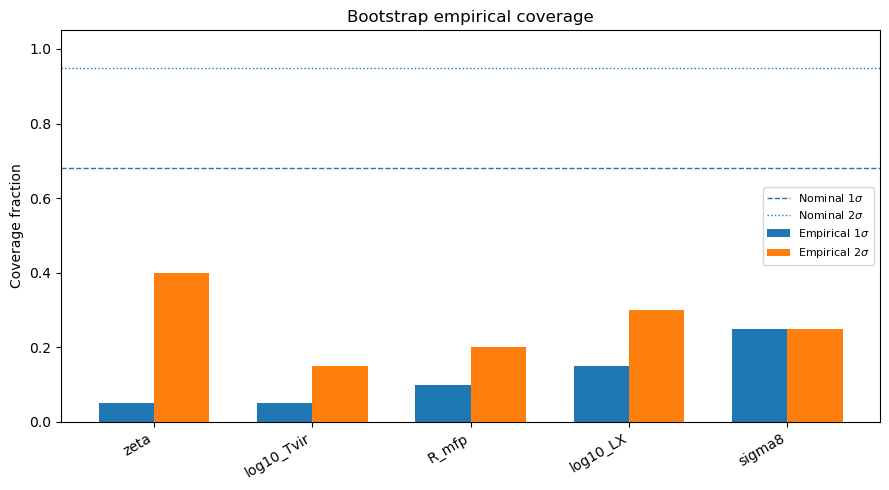

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_coverage_rf_n100_validation.png


In [16]:
x = np.arange(len(target_names))
width = 0.35

coverage_ordered = coverage_df.set_index("target").loc[target_names].reset_index()

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    coverage_ordered["coverage_1sigma"],
    width=width,
    label=r"Empirical $1\sigma$",
)

plt.bar(
    x + width / 2,
    coverage_ordered["coverage_2sigma"],
    width=width,
    label=r"Empirical $2\sigma$",
)

plt.axhline(0.68, linestyle="--", linewidth=1, label=r"Nominal $1\sigma$")
plt.axhline(0.95, linestyle=":", linewidth=1, label=r"Nominal $2\sigma$")

plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylabel("Coverage fraction")
plt.ylim(0, 1.05)
plt.title("Bootstrap empirical coverage")
plt.legend(fontsize=8)
plt.tight_layout()

coverage_fig_path = FIGURES / f"bootstrap_coverage_rf_{DATA_TAG}.png"
plt.savefig(coverage_fig_path, dpi=300)
plt.show()

print("Saved figure to:", coverage_fig_path)

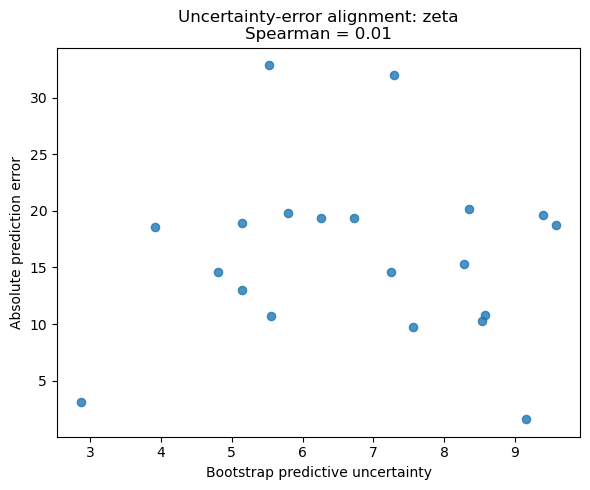

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/uncertainty_error_alignment_zeta_n100_validation.png


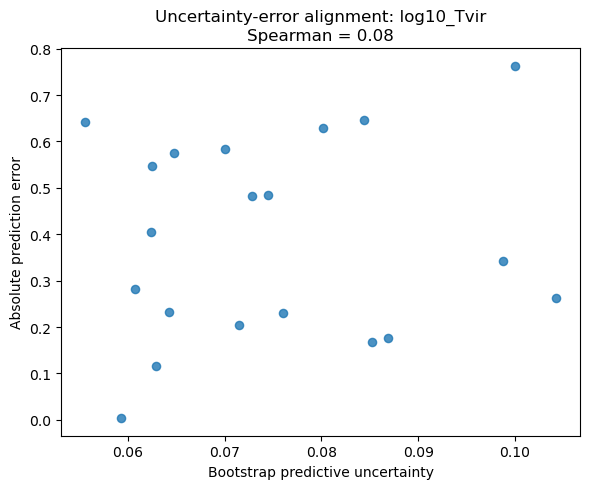

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/uncertainty_error_alignment_log10_Tvir_n100_validation.png


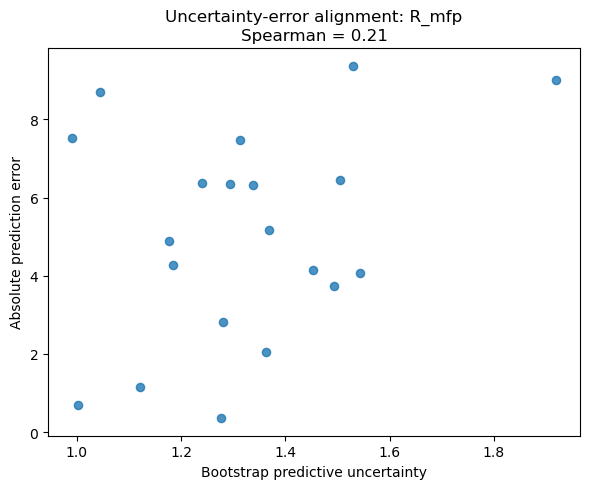

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/uncertainty_error_alignment_R_mfp_n100_validation.png


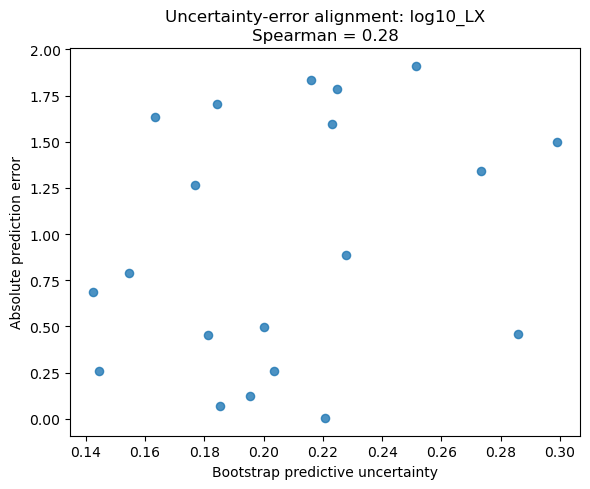

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/uncertainty_error_alignment_log10_LX_n100_validation.png


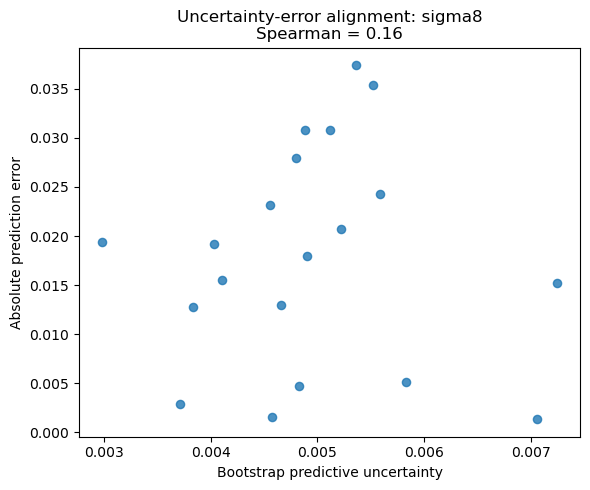

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/uncertainty_error_alignment_sigma8_n100_validation.png


In [17]:
for i, target in enumerate(target_names):

    abs_error = np.abs(y_test[:, i] - y_pred_mean[:, i])
    uncertainty = y_pred_std[:, i]

    rho = calibration_df.loc[
        calibration_df["target"] == target,
        "spearman_uncertainty_error"
    ].values[0]

    plt.figure(figsize=(6, 5))

    plt.scatter(
        uncertainty,
        abs_error,
        s=35,
        alpha=0.8,
    )

    plt.xlabel("Bootstrap predictive uncertainty")
    plt.ylabel("Absolute prediction error")
    plt.title(f"Uncertainty-error alignment: {target}\nSpearman = {rho:.2f}")
    plt.tight_layout()

    out_path = FIGURES / f"uncertainty_error_alignment_{target}_{DATA_TAG}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

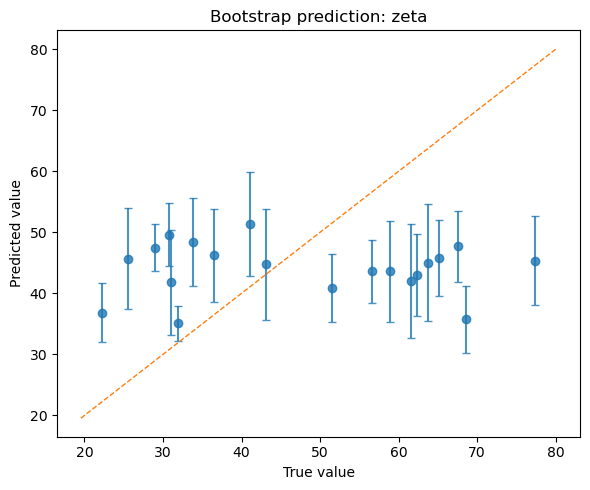

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_pred_vs_true_zeta_n100_validation.png


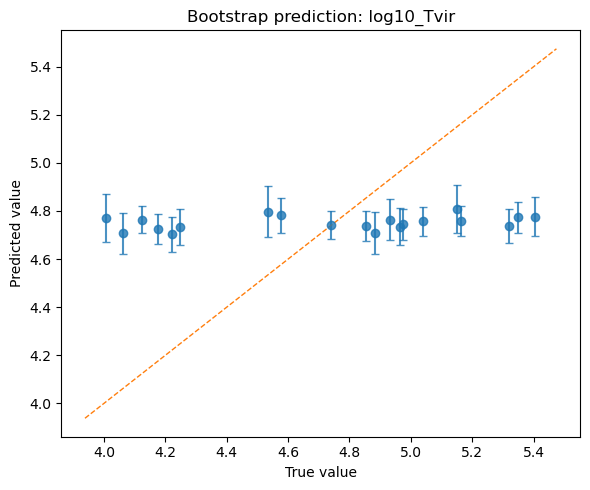

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_pred_vs_true_log10_Tvir_n100_validation.png


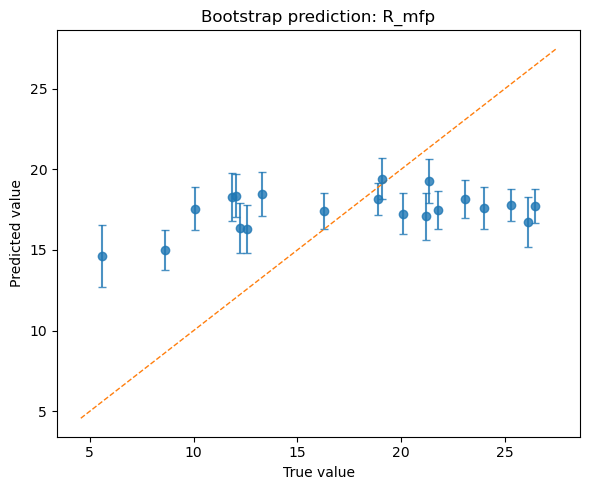

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_pred_vs_true_R_mfp_n100_validation.png


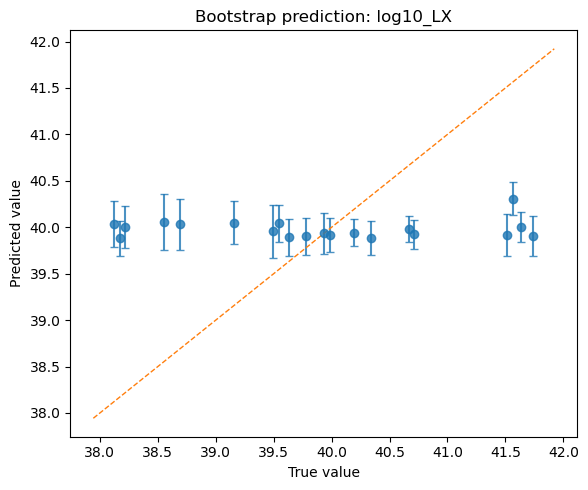

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_pred_vs_true_log10_LX_n100_validation.png


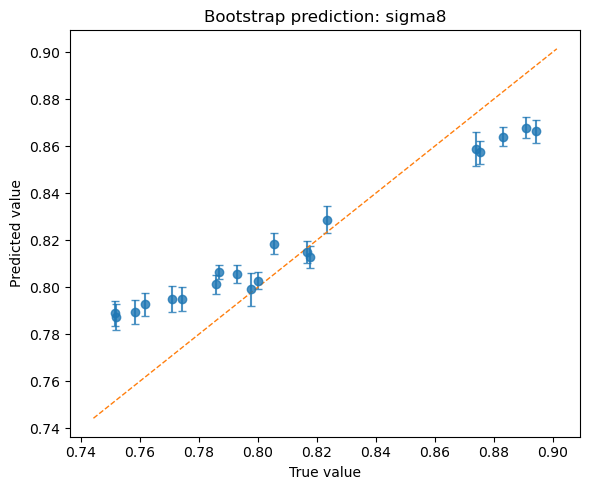

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/bootstrap_pred_vs_true_sigma8_n100_validation.png


In [18]:
for i, target in enumerate(target_names):

    y_true_i = y_test[:, i]
    mu_i = y_pred_mean[:, i]
    std_i = y_pred_std[:, i]

    y_min = min(np.min(y_true_i), np.min(mu_i))
    y_max = max(np.max(y_true_i), np.max(mu_i))
    pad = 0.05 * (y_max - y_min)

    plt.figure(figsize=(6, 5))

    plt.errorbar(
        y_true_i,
        mu_i,
        yerr=std_i,
        fmt="o",
        alpha=0.8,
        capsize=3,
    )

    plt.plot(
        [y_min - pad, y_max + pad],
        [y_min - pad, y_max + pad],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel("True value")
    plt.ylabel("Predicted value")
    plt.title(f"Bootstrap prediction: {target}")
    plt.tight_layout()

    out_path = FIGURES / f"bootstrap_pred_vs_true_{target}_{DATA_TAG}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print("Saved:", out_path)

In [19]:
bootstrap_summary = (
    bootstrap_performance
    .merge(coverage_df, on="target")
    .merge(calibration_df, on="target")
)

bootstrap_summary

,target,r2,mae,mean_pred_std,median_pred_std,coverage_1sigma,coverage_2sigma,nominal_1sigma,nominal_2sigma,spearman_uncertainty_error,p_value,mean_abs_error,mean_uncertainty
0,zeta,-0.138591,16.145756,6.787115,6.987153,0.05,0.40,0.68,0.95,0.009023,0.969885,16.145756,6.787115
1,log10_Tvir,0.034688,0.388779,0.074842,0.072139,0.05,0.15,0.68,0.95,0.084211,0.724104,0.388779,0.074842
2,R_mfp,0.135099,5.048353,1.321981,1.303710,0.10,0.20,0.68,0.95,0.206015,0.383533,5.048353,1.321981
3,log10_LX,-0.007175,0.952826,0.207698,0.201743,0.15,0.30,0.68,0.95,0.275188,0.240283,0.952826,0.207698
4,sigma8,0.798966,0.017963,0.004940,0.004855,0.25,0.25,0.68,0.95,0.160902,0.497974,0.017963,0.004940


In [20]:
bootstrap_summary_path = RESULTS / f"bootstrap_summary_rf_{DATA_TAG}.csv"

bootstrap_summary.to_csv(bootstrap_summary_path, index=False)

print("Saved bootstrap summary to:", bootstrap_summary_path)

Saved bootstrap summary to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_summary_rf_n100_validation.csv


In [21]:
bootstrap_metadata = {
    "notebook": "09_bootstrap_uncertainty.ipynb",
    "data_tag": DATA_TAG,
    "model": "RandomForestRegressor",
    "n_bootstrap": N_BOOTSTRAP,
    "n_trees_per_model": N_TREES,
    "n_train": int(X_train_raw.shape[0]),
    "n_test": int(X_test_raw.shape[0]),
    "n_features": int(X_train_raw.shape[1]),
    "n_targets": int(y_train.shape[1]),
    "target_names": target_names,
    "random_seed": RANDOM_SEED,
    "notes": (
        "Bootstrap uncertainty estimates are computed using independent "
        "Random Forest models trained on bootstrap-resampled training sets. "
        "This is an exploratory uncertainty diagnostic for the n=100 validation dataset."
    ),
}

bootstrap_metadata_path = RESULTS / f"bootstrap_metadata_rf_{DATA_TAG}.json"

with open(bootstrap_metadata_path, "w") as f:
    json.dump(bootstrap_metadata, f, indent=2)

print("Saved metadata to:", bootstrap_metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/bootstrap_metadata_rf_n100_validation.json


In [22]:
loaded_predictions = np.load(bootstrap_predictions_path)
loaded_mean = np.load(bootstrap_mean_path)
loaded_std = np.load(bootstrap_std_path)

assert loaded_predictions.shape == bootstrap_predictions.shape
assert loaded_mean.shape == y_pred_mean.shape
assert loaded_std.shape == y_pred_std.shape

print("Reload validation passed.")

Reload validation passed.


In [23]:
print("=" * 60)
print("Notebook 09 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Bootstrap models:", N_BOOTSTRAP)
print("Prediction array shape:", bootstrap_predictions.shape)

print("\nBootstrap performance:")
print(bootstrap_performance)

print("\nCoverage:")
print(coverage_df)

print("\nCalibration:")
print(calibration_df)

print("\nSaved files:")
print(" -", bootstrap_predictions_path)
print(" -", bootstrap_mean_path)
print(" -", bootstrap_std_path)
print(" -", bootstrap_performance_path)
print(" -", coverage_path)
print(" -", calibration_path)
print(" -", bootstrap_summary_path)
print(" -", coverage_fig_path)
print(" -", bootstrap_metadata_path)

Notebook 09 completed successfully.
Dataset tag: n100_validation
Bootstrap models: 20
Prediction array shape: (20, 20, 5)

Bootstrap performance:
       target        r2        mae  mean_pred_std  median_pred_std
0        zeta -0.138591  16.145756       6.787115         6.987153
1  log10_Tvir  0.034688   0.388779       0.074842         0.072139
2       R_mfp  0.135099   5.048353       1.321981         1.303710
3    log10_LX -0.007175   0.952826       0.207698         0.201743
4      sigma8  0.798966   0.017963       0.004940         0.004855

Coverage:
       target  coverage_1sigma  coverage_2sigma  nominal_1sigma  \
0        zeta             0.05             0.40            0.68   
1  log10_Tvir             0.05             0.15            0.68   
2       R_mfp             0.10             0.20            0.68   
3    log10_LX             0.15             0.30            0.68   
4      sigma8             0.25             0.25            0.68   

   nominal_2sigma  
0            0.95 